# Ice Recrystallization Inhibition (Two Critical Radii)

This notebook shows a minimal run of the IRI model with:
- one melting critical radius,
- one freezing critical radius,
- a stay region between them where growth velocity is zero.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from iri_model import run_simulation, critical_radii

In [ ]:
# Radius grid (micrometer)
R = np.linspace(0.1, 40.0, 400)

# Initial particle size distribution (Gaussian)
# f(R) unit: 1/µm^4 so that ∫f(R)dR gives number density [1/µm^3]
n = 100
V = 170**3  # [µm^3]
mean_R = 10.0
std_R = 2.0
A = n / (std_R * V * np.sqrt(2.0 * np.pi))
f_init = A * np.exp(-0.5 * ((R - mean_R) / std_R) ** 2)

# Initial concentration [number/µm^3]
c_bulk_init = 2.2e10

# Model parameters
params = {
    "D": 1120.0,       # [µm^2/s]
    "rho_ice": 3.04e11, # [number/µm^3]
    "c_flat": 1.8e10,   # [number/µm^3]
    "alpha": 5.5e9,     # [number/µm^2]
    "k1": 3.87e4,       # [number/µm^2]
    "k2": 3.87e4,       # [number/µm^2]
    "invL2": 100.0,     # [1/µm]
    "time_unit": "s",  # 's' (default) or 'ms'
}

R_melt0, R_freeze0 = critical_radii(c_bulk_init, params)
print(f"Initial melt critical radius:   {R_melt0:.3f} µm")
print(f"Initial freeze critical radius: {R_freeze0:.3f} µm")

Initial melt critical radius:   1.374 µm
Initial freeze critical radius: 1.376 µm


In [3]:
# Run simulation (seconds)
t_eval = np.linspace(0.0, 3600.0, 120)
sol = run_simulation(
    f_init=f_init,
    c_bulk_init=c_bulk_init,
    R=R,
    t_span=(0.0, 3600.0),
    t_eval=t_eval,
    params=params,
    mode="double",  # uses two critical radii with stay region
)

f_final = sol.y[:-1, -1]
c_bulk_final = sol.y[-1, -1]
print(f"Solver success: {sol.success}")
print(f"Final c_bulk: {c_bulk_final:.4e}")

Solver success: True
Final c_bulk: 1.8528e+10


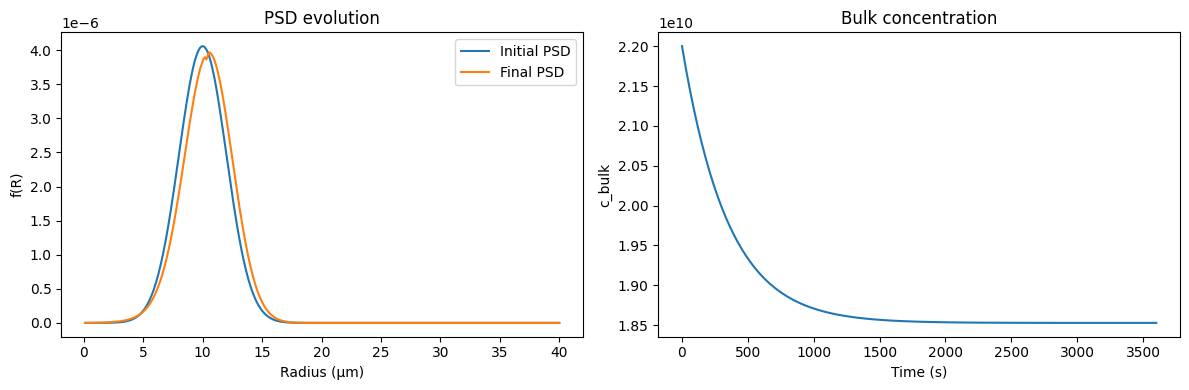

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(R, f_init, label="Initial PSD")
axes[0].plot(R, f_final, label="Final PSD")
axes[0].set_xlabel("Radius (µm)")
axes[0].set_ylabel("f(R) [1/µm⁴]")
axes[0].set_title("PSD evolution")
axes[0].legend()

axes[1].plot(sol.t, sol.y[-1, :])
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("c_bulk [number/µm³]")
axes[1].set_title("Bulk concentration")

plt.tight_layout()
plt.show()